In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import itertools
from collections import deque

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
pd.options.display.float_format='{:,.2f}'.format

In [4]:
def moving(origin,step):
    it=iter(origin)
    data=deque(itertools.islice(it,step-1))
    s=sum(data)
    data.appendleft(0)
    for elem in it:
        s+=elem-data.popleft()
        data.append(elem)
        yield round(s/step,2)

In [5]:
if __name__ == '__main__':
    step_value = 3
    origin_data=[260,229,251,239,263,255,247,259,242,253,249,254]
    forecast=list(moving(origin_data,step_value))

In [6]:
print("预测值:",forecast)

预测值: [246.67, 239.67, 251.0, 252.33, 255.0, 253.67, 249.33, 251.33, 248.0, 252.0]


In [7]:
forecast=origin_data[:step_value]+forecast
origin_data=origin_data+origin_data[-1:]

In [8]:
def plt_show(origin_data,forecast_data):
    x_axis_data=[1,2,3,4,5,6,7,8,9,10,11,12,"2021.01"]
    plt.plot(x_axis_data,forecast_data,'bo-',label="预测值")
    plt.plot(x_axis_data,origin_data,'r*-',label="实际值")
    plt.legend()
    plt.grid()
    plt.xlabel("月份")
    plt.ylabel("销售量")
    plt.show()

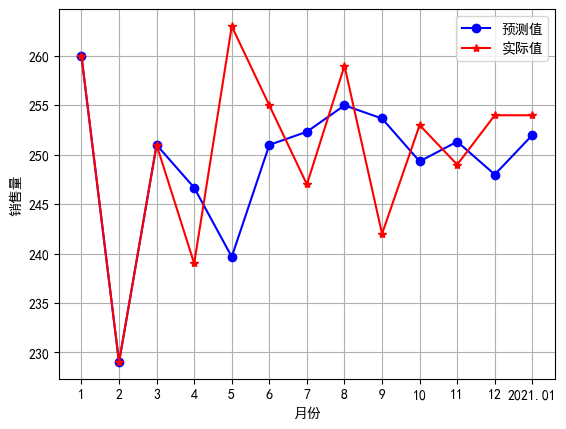

In [9]:
plt_show(origin_data,forecast)

In [10]:
def moving(actual_data,coeff_a,first_forecast=None):
    forecast_data=[]
    if not first_forecast:
        forecast_data.append(actual_data[0])
    else:
        forecast_data.append(first_forecast)
    for data in actual_data:
        forecast_value=coeff_a*data+(1-coeff_a)*forecast_data[-1]
        forecast_data.append(round(forecast_value,2))
    return forecast_data

In [11]:
if __name__=="__main__":
    a=0.3
    first_value=257
    origin_value=[260,229,251,239,263,255,247,259,242,253,249,254]
    smooth_value=moving(origin_value,a,first_value)


In [12]:
print("预测值:",smooth_value)

预测值: [257, 257.9, 249.23, 249.76, 246.53, 251.47, 252.53, 250.87, 253.31, 249.92, 250.84, 250.29, 251.4]


In [13]:
origin_x_data=["1","2","3","4","5","6","7","8","9","10","11","12"]
forecast_x_data=["1","2","3","4","5","6","7","8","9","10","11","12","2023.01"]

In [14]:
def plot_show2(origin_axis,origin_data,forecast_axis,forecast_data):
    with plt.style.context('seaborn-v0_8-white'):
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.plot(origin_axis, origin_data, 'r*-',label = '实际值')
        plt.plot(forecast_axis, forecast_data, 'bo-',label = '预测值')
        plt.legend(loc = 'best')
        plt.grid(True)
        plt.xlabel("月份")
        plt.ylabel("销售量")
        plt.show()

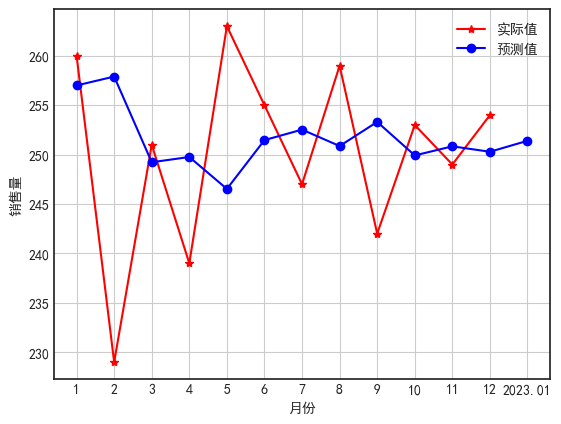

In [15]:
plot_show2(origin_x_data,origin_value,forecast_x_data,smooth_value)

In [16]:
data2 =[[1,501],
        [2,513],
        [3,540],
        [4,546],
        [5,577],
        [6,588],
        [7,614],
        [8,630],
        [9,639]]

In [17]:
mg=pd.DataFrame(data2,columns=['月份','销售量'])
mg

,月份,销售量
0,1,501
1,2,513
2,3,540
3,4,546
4,5,577
5,6,588
6,7,614
7,8,630
8,9,639


In [18]:
xs=mg.corr()
print(xs)

      月份  销售量
月份  1.00 0.99
销售量 0.99 1.00


In [19]:
x=mg['月份']
y=mg['销售量']

In [20]:
poly=np.polyfit(x,y,deg=1)
poly

array([ 18.21666667, 480.91666667])

In [21]:
z=np.polyval(poly,x)

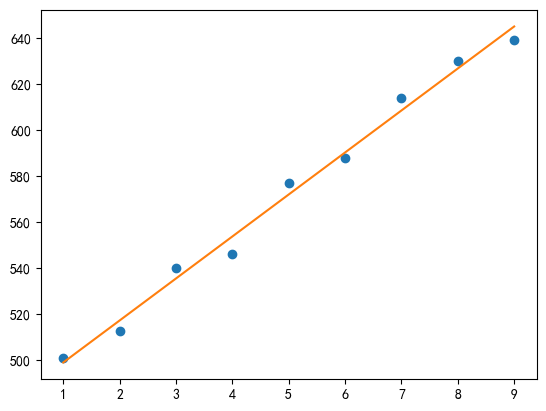

In [22]:
plt.plot(x,y,'o')
plt.plot(x,z)
plt.show()

In [23]:
z10=np.polyval(poly,10)
z11=np.polyval(poly,11)
z12=np.polyval(poly,12)
print (z10,z11,z12)

663.0833333333334 681.3 699.5166666666667
